In [ ]:
!wget -q "https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh" -O "/tmp/fenicsx-install.sh"
!bash "/tmp/fenicsx-install.sh"

+ INSTALL_PREFIX=/usr/local
++ awk -F/ '{print NF-1}'
++ echo /usr/local
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICSX_INSTALLED=/usr/local/share/fem-on-colab/fenicsx.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenicsx.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/ec24876d/releases/pybind11-install.sh
+ [[ https://github.com/fem-on-colab/fem-on-colab.github.io/raw/ec24876d/releases/pybind11-install.sh == http* ]]
+ PYBIND11_INSTALL_SCRIPT_DOWNLOAD=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/ec24876d/releases/pybind11-install.sh
+ PYBIND11_INSTALL_SCRIPT_PATH=/tmp/pybind11-install.sh
+ [[ ! -f /tmp/pybind11-install.sh ]]
+ wget https://github.com/fem-on-colab/fem-on-colab.github.io/raw/ec24876d/releases/pybind11-install.sh -O /tmp/pybind11-install.sh
--2025-08-04 21:43:20--  https://github.com/fem-on-colab/fem-on-colab.github.io/raw/ec24876d/release

In [ ]:
!pip install pyvista
!apt-get install -y xvfb libgl1-mesa-glx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 MB 8.9 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgl1-mesa-glx is already the newest version (23.0.4-0ubuntu1~22.04.1).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.15).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
import numpy as np
import pandas as pd
import pyvista
from pyvista.plotting.utilities import xvfb
xvfb.start_xvfb()

from dolfinx import mesh, fem, plot
from dolfinx.fem import Function, dirichletbc, locate_dofs_topological
from dolfinx.fem.petsc import assemble_matrix, assemble_vector, apply_lifting, set_bc
import ufl
from mpi4py import MPI
from petsc4py import PETSc
from IPython.display import Image

/usr/local/lib/python3.11/dist-packages/pyvista/plotting/utilities/xvfb.py:48: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk-osmesa instead.
  warnings.warn(


# Ejercicio 1: Problema de Poisson en un dominio rectangular  
## Dominio: $\Omega = [0, 1]^2$

Consideremos el siguiente **problema de Poisson bidimensional** en el dominio cuadrado:

$$
- \Delta u(x, y) = f(x, y) \tag{1}
$$

con condición de contorno:

$$
u = 0 \quad \text{en } \partial \Omega
$$

donde el término fuente es:

$$
f(x, y) = 2\pi^2 \sin(\pi x)\sin(\pi y) \tag{2}
$$

La **solución exacta** de este problema es:

$$
u(x, y) = \sin(\pi x)\sin(\pi y) \tag{3}
$$

---

### 🎯 Objetivo

Implementar un programa utilizando el **método de elementos finitos** con elementos triangulares **$P_1$ (lineales por partes)** para resolver el **Problema de Valor de Contorno** descrito en (1).


In [ ]:
# ----------------------------
# Dominio y espacio de funciones
# ----------------------------
domain = mesh.create_unit_square(MPI.COMM_WORLD, 15, 15)
V = fem.functionspace(domain, ("CG", 1))

# ----------------------------
# Condiciones de contorno homogéneas
# ----------------------------
u_D = fem.Function(V)
u_D.x.array[:] = 0.0

facets = mesh.locate_entities_boundary(domain, dim=1, marker=lambda x: np.full(x.shape[1], True))
dofs = locate_dofs_topological(V, 1, facets)
bc = dirichletbc(u_D, dofs)

# ----------------------------
# Término fuente f(x, y) = 2π² sin(πx) sin(πy)
# ----------------------------
f = fem.Function(V)
f.interpolate(lambda x: 2 * np.pi**2 * np.sin(np.pi * x[0]) * np.sin(np.pi * x[1]))

# ----------------------------
# Formulación variacional
# ----------------------------
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
a = ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = f * v * ufl.dx

a_form = fem.form(a)
L_form = fem.form(L)

# ----------------------------
# Ensamblar sistema
# ----------------------------
A = assemble_matrix(a_form, bcs=[bc])
A.assemble()

b = assemble_vector(L_form)
apply_lifting(b, [a_form], bcs=[[bc]])
b.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
set_bc(b, [bc])

# ----------------------------
# Resolver el sistema
# ----------------------------
x = b.duplicate()
x.set(0.0)

solver = PETSc.KSP().create(domain.comm)
solver.setOperators(A)
solver.setType("cg")
solver.getPC().setType("ilu")
solver.solve(b, x)

uh = fem.Function(V)
uh.x.array[:] = x.array
uh.x.scatter_forward()


Campos escalares disponibles: ['vtkOriginalPointIds', 'vtkGhostType', 'u']


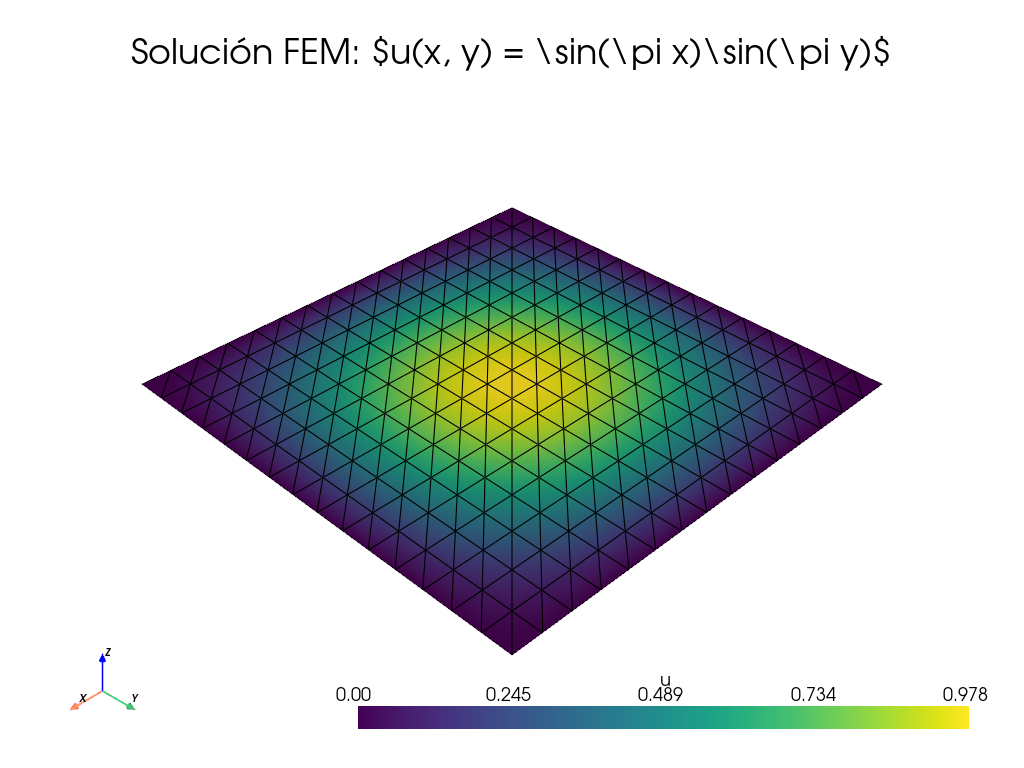

In [ ]:
# ----------------------------
# Exportar solución a formato Paraview
# ----------------------------
from dolfinx.io import VTKFile
from IPython.display import Image
import pyvista

# Nombrar la función (importante para exportar con nombre de campo escalar)
uh.name = "u"

# Guardar archivo .pvd + .vtu
vtkfile = VTKFile(domain.comm, "solucion_poisson.pvd", "w")
vtkfile.write_function(uh)

# ----------------------------
# Leer el archivo generado
# ----------------------------
grid = pyvista.read("solucion_poisson_p0_000000.vtu")
print("Campos escalares disponibles:", grid.point_data.keys())

# ----------------------------
# Visualizar la solución
# ----------------------------
plotter = pyvista.Plotter(off_screen=True)
plotter.add_mesh(
    grid,
    scalars="u",
    cmap="viridis",
    show_edges=True
)

plotter.add_title("Solución FEM: $u(x, y) = \sin(\pi x)\sin(\pi y)$", font_size=14)
plotter.set_background("white")
plotter.show_axes()

# Guardar la imagen
plotter.screenshot("solucion_exacta.png")

# Mostrar en notebook
Image("solucion_exacta.png")


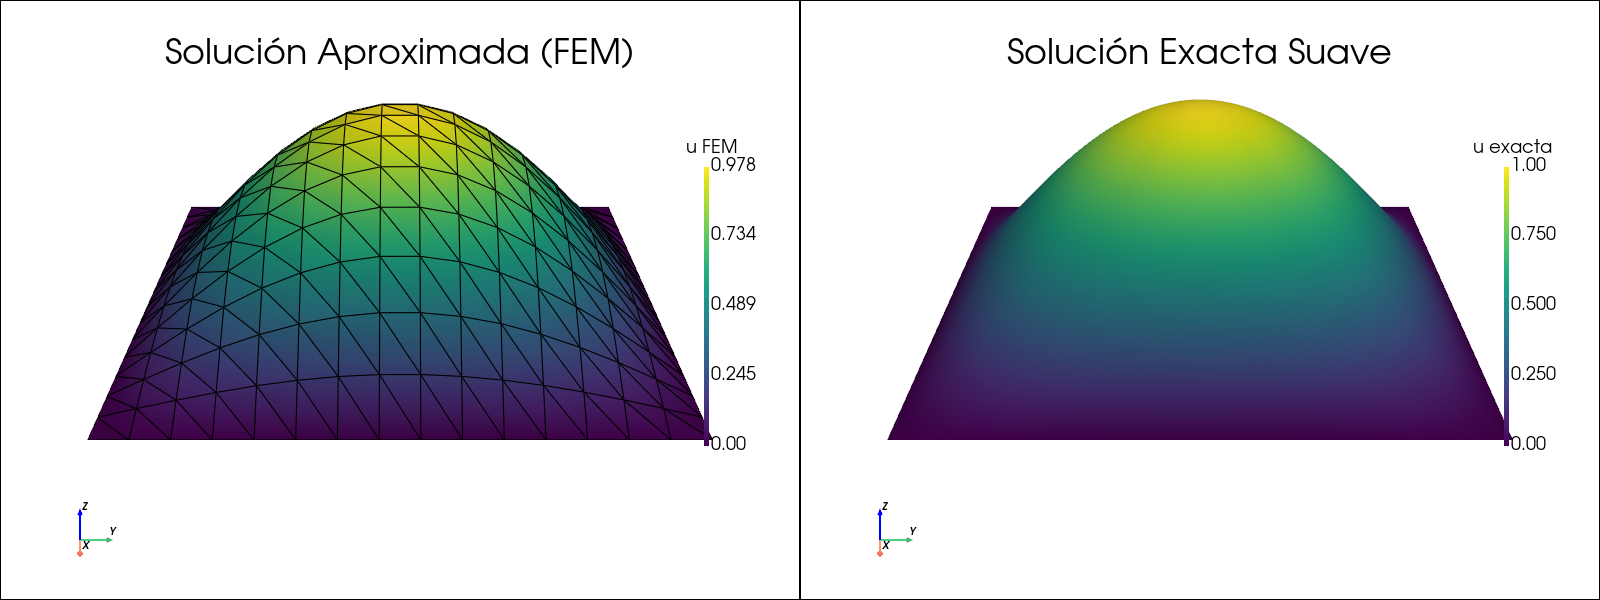

In [ ]:
import pyvista
import numpy as np
from IPython.display import display, Image

# ----------------------------
# 1. Leer solución FEM desde .vtu
# ----------------------------
grid_fem = pyvista.read("solucion_poisson_p0_000000.vtu")
coords_fem = np.array(grid_fem.points)
n_nodes = grid_fem.n_points
u_fem_vals = grid_fem.point_data["u"]

# ----------------------------
# 2. Crear solución exacta suave sobre malla densa
# ----------------------------
n = 100
x = np.linspace(0, 1, n)
y = np.linspace(0, 1, n)
xx, yy = np.meshgrid(x, y, indexing="ij")
zz = np.sin(np.pi * xx) * np.sin(np.pi * yy)

grid_exacta = pyvista.StructuredGrid()
grid_exacta.points = np.c_[xx.ravel(), yy.ravel(), np.zeros_like(xx).ravel()]
grid_exacta.dimensions = (n, n, 1)
grid_exacta["u_exacta"] = zz.ravel()

# ----------------------------
# 3. Escalado visual uniforme para ambos
# ----------------------------
altura_visual = 0.4
max_valor = max(np.max(np.abs(u_fem_vals)), 1.0)  # la exacta llega a 1
factor_visual = altura_visual / max_valor

# ----------------------------
# 4. Crear escena lado a lado (FEM izquierda, exacta derecha)
# ----------------------------
plotter = pyvista.Plotter(shape=(1, 2), window_size=(1600, 600), off_screen=True)

# --- Subplot 0: Solución FEM (izquierda) ---
plotter.subplot(0, 0)
mesh_fem = grid_fem.warp_by_scalar("u", factor=factor_visual)
plotter.add_mesh(
    mesh_fem,
    scalars="u",
    cmap="viridis",
    show_edges=True,
    scalar_bar_args={
        "title": "u FEM",
        "vertical": True,
        "position_x": 0.88,
        "position_y": 0.25,
        "width": 0.02,
        "height": 0.5,
    }
)
plotter.add_title("Solución Aproximada (FEM)", font_size=14)
plotter.camera_position = [(2.5, 0.5, 1), (0.5, 0.5, 0), (0, 0, 1)]
plotter.set_background("white")
plotter.show_axes()

# --- Subplot 1: Solución exacta suave (derecha) ---
plotter.subplot(0, 1)
mesh_exacta = grid_exacta.warp_by_scalar("u_exacta", factor=factor_visual)
plotter.add_mesh(
    mesh_exacta,
    scalars="u_exacta",
    cmap="viridis",
    show_edges=False,
    scalar_bar_args={
        "title": "u exacta",
        "vertical": True,
        "position_x": 0.88,
        "position_y": 0.25,
        "width": 0.02,
        "height": 0.5,
    }
)
plotter.add_title("Solución Exacta Suave", font_size=14)
plotter.camera_position = [(2.5, 0.5, 1), (0.5, 0.5, 0), (0, 0, 1)]
plotter.set_background("white")
plotter.show_axes()

# ----------------------------
# 5. Guardar imagen y mostrar
# ----------------------------
plotter.screenshot("comparacion_fem_vs_exacta.png")
display(Image("comparacion_fem_vs_exacta.png"))


## Problema resuelto: Ecuación de Poisson en el cuadrado unidad

En este experimento numérico se resuelve la **ecuación de Poisson** en dos dimensiones sobre el dominio cuadrado unidad \( \Omega = (0,1)\times(0,1) \):

$$
- \Delta u(x,y) = f(x,y), \quad \text{en } \Omega,
$$

$$
u(x,y) = 0, \quad \text{sobre } \partial\Omega.
$$

Donde:

- \( \Delta \) es el operador Laplaciano:  
  $$ \Delta u = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} $$
- \( f(x,y) \) es una fuente localizada definida como:

$$
f(x,y) = 10 \cdot \exp\left(-5\left((x - 0.5)^2 + (y - 0.5)^2\right)\right)
$$

Esto representa una **fuente gaussiana** centrada en el punto \( (0.5, 0.5) \).

- Se imponen **condiciones de frontera homogéneas**:  
  $$ u = 0 \quad \text{en todo } \partial\Omega. $$


In [ ]:
domain = mesh.create_unit_square(MPI.COMM_WORLD, 20, 20)
V = fem.functionspace(domain, ("CG", 1))

u_D = Function(V)
u_D.x.array[:] = 0.0

facets = mesh.locate_entities_boundary(domain, dim=1, marker=lambda x: np.full(x.shape[1], True))
dofs = locate_dofs_topological(V, 1, facets)
bc = dirichletbc(u_D, dofs)


f = Function(V)
f.interpolate(lambda x: 10*np.exp(-5*((x[0]-0.5)**2 + (x[1]-0.5)**2)))



u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
a = ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = f * v * ufl.dx

a_form = fem.form(a)
L_form = fem.form(L)



# Ensamblar la matriz del sistema
A = assemble_matrix(a_form, bcs=[bc])
A.assemble()

# Ensamblar el vector del lado derecho
b = assemble_vector(L_form)
apply_lifting(b, [a_form], bcs=[[bc]])
b.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
set_bc(b, [bc])

# Crear el vector solución como PETSc.Vec con misma estructura que b
x = b.duplicate()
x.set(0.0)

# Crear y configurar el solver
solver = PETSc.KSP().create(domain.comm)
solver.setOperators(A)
solver.setType("cg")
solver.getPC().setType("ilu")

# Resolver el sistema lineal
solver.solve(b, x)

# Copiar el resultado a la función uh
uh = fem.Function(V)
uh.x.array[:] = x.array
uh.x.scatter_forward()


In [ ]:
import os
os.listdir()


['.config',
 'solucion_poisson_p0_000000.vtu',
 'solucion_poisson.pvd',
 'solucion.png',
 'solucion_elevada.png',
 'solucion_poisson000000.pvtu',
 'sample_data']

Campos escalares disponibles: ['vtkOriginalPointIds', 'vtkGhostType', 'u']


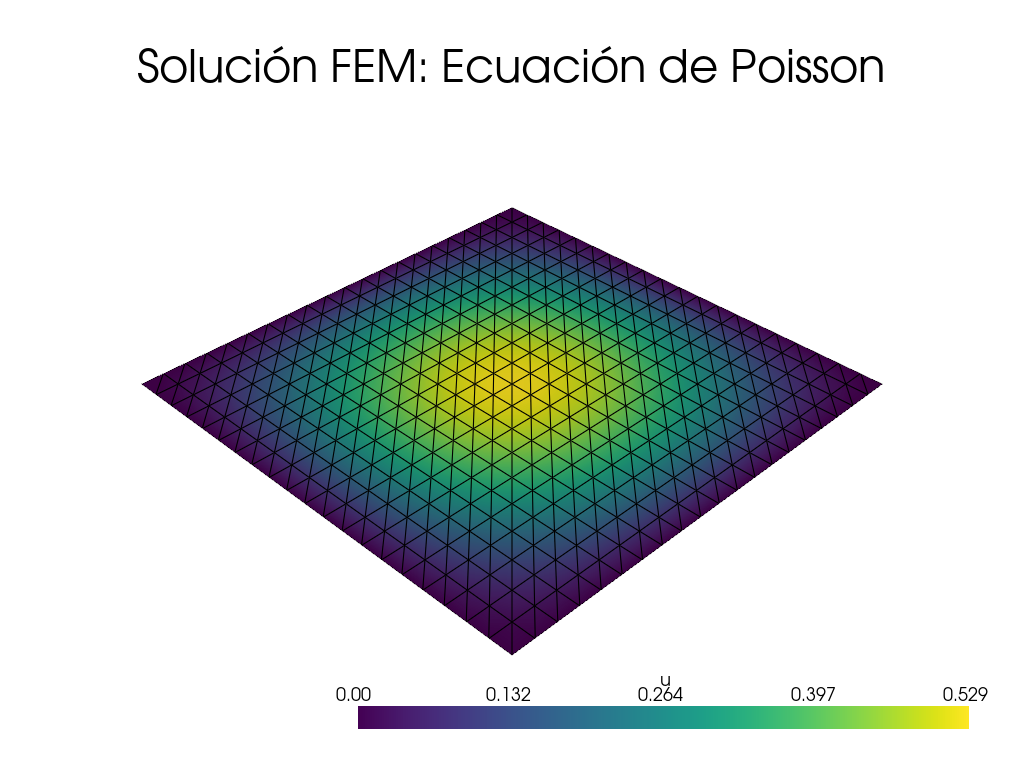

In [ ]:
from dolfinx.io import VTKFile
from IPython.display import Image
import pyvista

#Nombra la función para que se exporte correctamente
uh.name = "u"

# Guardar en formato Paraview .pvd + .vtu
vtk = VTKFile(domain.comm, "solucion_poisson.pvd", "w")
vtk.write_function(uh)

# -------------------------------
# ✅ Leer el archivo generado
# -------------------------------
grid = pyvista.read("solucion_poisson_p0_000000.vtu")

# Confirmar qué datos escalar tiene disponibles
print("Campos escalares disponibles:", grid.point_data.keys())

# -------------------------------
# ✅ Visualizar
# -------------------------------
plotter = pyvista.Plotter(off_screen=True)
plotter.add_mesh(grid, scalars="u", cmap="viridis", show_edges=True)
plotter.add_title("Solución FEM: Ecuación de Poisson")
plotter.screenshot("solucion.png")

# Mostrar imagen
Image("solucion.png")


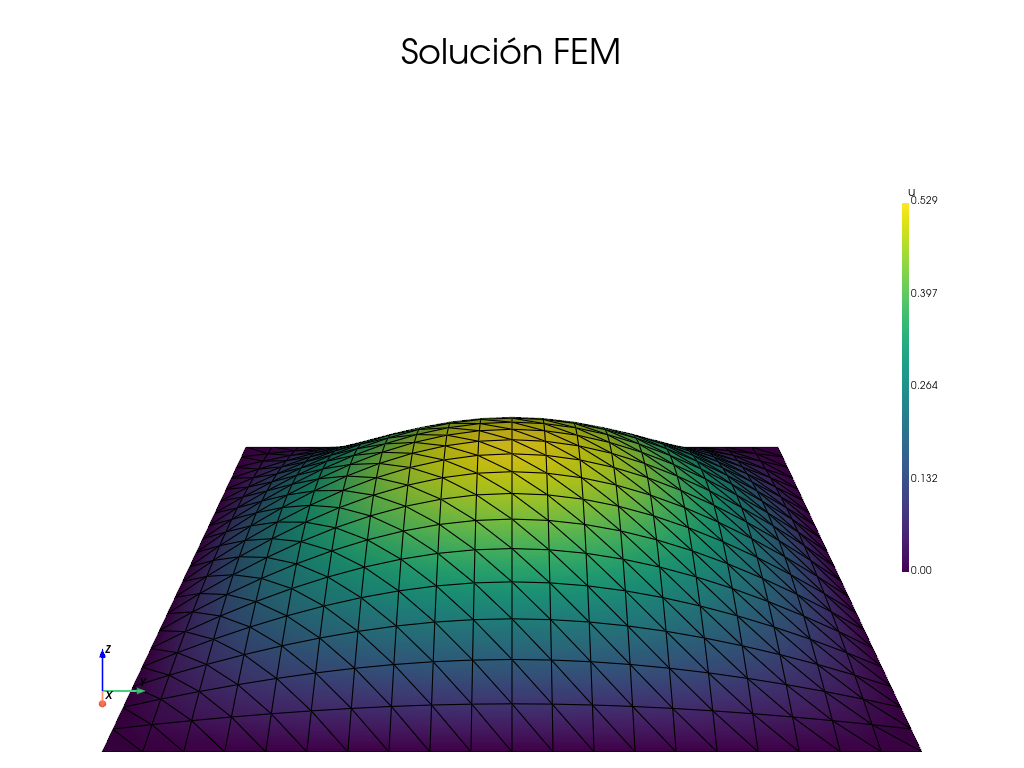

In [ ]:
plotter = pyvista.Plotter(off_screen=True)

# Elevar la malla según la solución u
mesh_warped = grid.warp_by_scalar("u", factor=0.4)

# Añadir la malla coloreada con barra de color vertical a la derecha
plotter.add_mesh(
    mesh_warped,
    scalars="u",
    cmap="viridis",
    show_edges=True,
    scalar_bar_args={
        "title": "u",
        "vertical": True,
        "position_x": 0.88,     # posición horizontal (derecha)
        "position_y": 0.25,     # posición vertical (centrado bajo el título)
        "width": 0.02,          # ancho de la barra
        "height": 0.5,          # alto de la barra
        "title_font_size": 12,
        "label_font_size": 10,
    }
)

# Título
plotter.add_title("Solución FEM", font_size=14)

# Mostrar ejes clásicos (sin caja)
plotter.show_axes()

# Cámara más baja, mirando desde un costado
plotter.camera_position = [
    (2.5, 0.5, 1),      # ubicación de la cámara (costado y bajo)
    (0.5, 0.5, 0.3),    # punto de enfoque
    (0, 0, 1)           # eje vertical
]

# Fondo blanco
plotter.set_background("white")

# Captura la imagen
plotter.screenshot("solucion_elevada.png")

# Mostrar imagen
Image("solucion_elevada.png")
